In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [2]:
df_book = pd.read_parquet(r"C:\Users\Quang\Documents\USTH\FundDS\dataset\mart_book_statistics.parquet")

# Overview

In [3]:
df = df_book.copy()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2363585 entries, 0 to 2363584
Data columns (total 21 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   book_id                    int32  
 1   title                      str    
 2   title_without_series       str    
 3   author_names               object 
 4   num_pages                  float64
 5   average_rating             float32
 6   ratings_count              float64
 7   country_code               str    
 8   language_code              str    
 9   publisher                  str    
 10  publication_year           float64
 11  book_url                   str    
 12  image_url                  str    
 13  genre_1                    str    
 14  genre_2                    str    
 15  genre_3                    str    
 16  genre_4                    str    
 17  genre_5                    str    
 18  series_names               object 
 19  original_title             str    
 20  original_publ

In [5]:
df.describe().map('{:,.2f}'.format)

,book_id,num_pages,average_rating,ratings_count,publication_year,original_publication_year
count,"2,363,585.00","1,599,212.00","2,362,620.00","2,363,061.00","1,763,946.00","2,081,414.00"
mean,"15,484,651.08",263.68,3.87,578.31,"2,007.64","1,991.81"
std,"11,212,114.88",829.22,0.54,"24,541.89",247.87,176.89
min,1.00,0.00,0.00,0.00,0.00,"-2,600.00"
25%,"5,986,497.00",147.00,3.63,6.00,"2,004.00","1,998.00"
50%,"15,870,053.00",246.00,3.91,20.00,"2,011.00","2,009.00"
75%,"24,440,615.00",344.00,4.16,77.00,"2,014.00","2,013.00"
max,"258,563,956.00","945,077.00",5.00,"11,810,403.00","65,535.00","32,767.00"


In [6]:
print("Total rows:", len(df))
print("Unique book_id:", df["book_id"].nunique())
print("Duplicate book_id:", df["book_id"].duplicated().sum())

Total rows: 2363585
Unique book_id: 2363585
Duplicate book_id: 0


In [8]:
df.isnull().sum()

book_id                            0
title                              0
title_without_series            2930
author_names                       0
num_pages                     764373
average_rating                   965
ratings_count                    524
country_code                    2930
language_code                     90
publisher                        262
publication_year              599639
book_url                           0
image_url                         44
genre_1                       418195
genre_2                       780754
genre_3                       996233
genre_4                      1209580
genre_5                      1592395
series_names                       0
original_title                  1742
original_publication_year     282171
dtype: int64

### Invalid Values

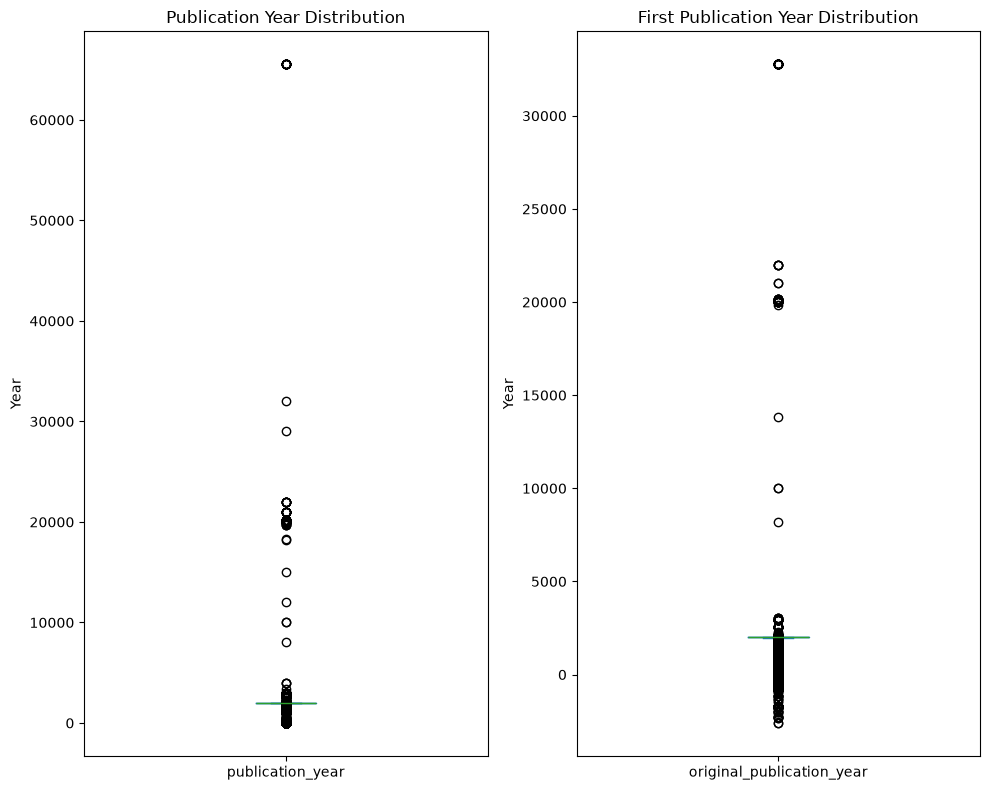

In [9]:
df2 = df.copy()
fig, ax = plt.subplots(1,2, figsize=(10,8))

df2['publication_year'].plot(kind='box', ax=ax[0])
ax[0].set_title('Publication Year Distribution')
ax[0].set_ylabel('Year')

df2['original_publication_year'].plot(kind='box', ax=ax[1])
ax[1].set_title('First Publication Year Distribution')
ax[1].set_ylabel('Year')

fig.tight_layout()
plt.show()

publication year có rất nhiều invalid value, theo tìm hiểu thì có rất nhiều sách điền ttin year trên web sai (vd: https://www.goodreads.com/book/show/16038054) (nhiều sách viết nhầm như 2014 -> 2104)

In [10]:
df[(df['original_publication_year'] > 2027) & (df['publication_year'] != df['original_publication_year'])][['book_id', 'title', 'average_rating', 'publication_year', 'original_publication_year', 'book_url']].sample(5)

,book_id,title,average_rating,publication_year,original_publication_year,book_url
1219039,16038054,ふしぎな夢,3.75,NaN,32767.0,https://www.goodreads.com/book/show/16038054
2185822,34849985,Tooth Fairy,4.25,2017.0,20117.0,https://www.goodreads.com/book/show/34849985-t...
957026,25680889,Likhe,4.50,2065.0,2053.0,https://www.goodreads.com/book/show/25680889-l...
1654935,21836395,จักรวาลรัก,3.86,2014.0,2557.0,https://www.goodreads.com/book/show/21836395
1088163,1773058,ABC of the Arab World,3.00,65535.0,32767.0,https://www.goodreads.com/book/show/1773058.AB...


In [4]:
df.loc[df["publication_year"] > 2026, "publication_year"] = np.nan
df.loc[df["original_publication_year"] > 2026, "original_publication_year"] = np.nan
for col in ["country_code", "language_code", "publisher"]:
    df[col] = (df[col].astype("string").str.strip().replace("", np.nan))

In [5]:
df[['num_pages', 'ratings_count']] = df[['num_pages', 'ratings_count']].astype('Int32')
df['average_rating'] = df['average_rating'].astype('float64')
df[['publication_year', 'original_publication_year']] = df[['publication_year', 'original_publication_year']].astype('Int16')

In [6]:
df = df.drop(columns=['title_without_series', 'country_code'])

In [7]:
df.loc[df['book_id'] == 33590260, ['title', 'original_title']] = ['Kingdom of Ash (Throne of Glass, #7)', 'Kingdom of Ash']

# EDA

### Data Quality

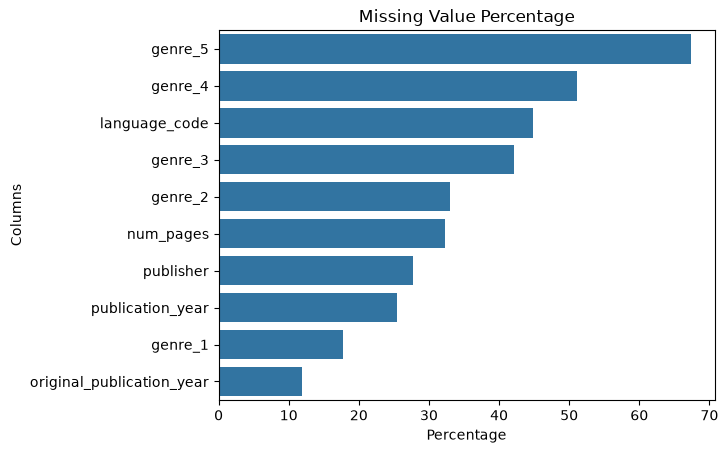

In [14]:
df2 = df.copy()

plot1 = ((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False).head(10)

sns.barplot(x=plot1.values, y=plot1.index)
plt.xlabel('Percentage')
plt.ylabel('Columns')
plt.title('Missing Value Percentage')

plt.tight_layout
plt.show()

### Ratings & Popularity

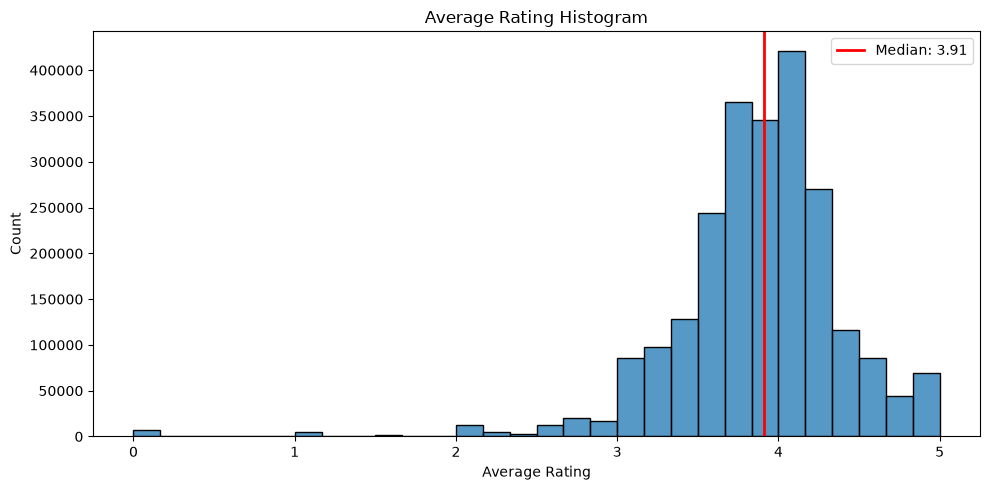

In [15]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(df2['average_rating'], bins=30)
ax.axvline(df2['average_rating'].median(), color='red', linestyle='-', linewidth=2, label=f'Median: {df2['average_rating'].median():.2f}')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Count')
ax.set_title('Average Rating Histogram')
ax.legend()

plt.tight_layout()
plt.show()

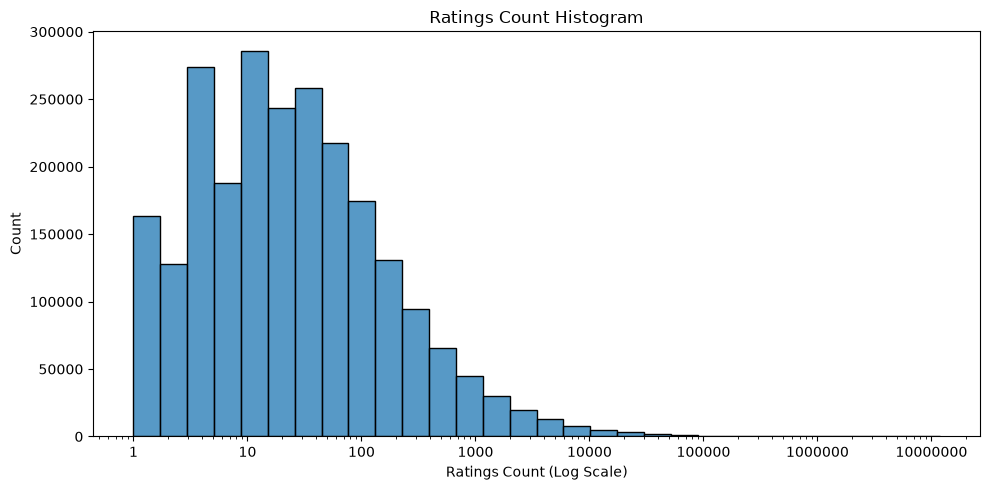

In [16]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2[df2['ratings_count'] > 0]['ratings_count'], bins=30, log_scale=True, ax=ax)
ax.set_xlabel('Ratings Count (Log Scale)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}'))
ax.set_title('Ratings Count Histogram')

plt.tight_layout()
plt.show()

ratings_count

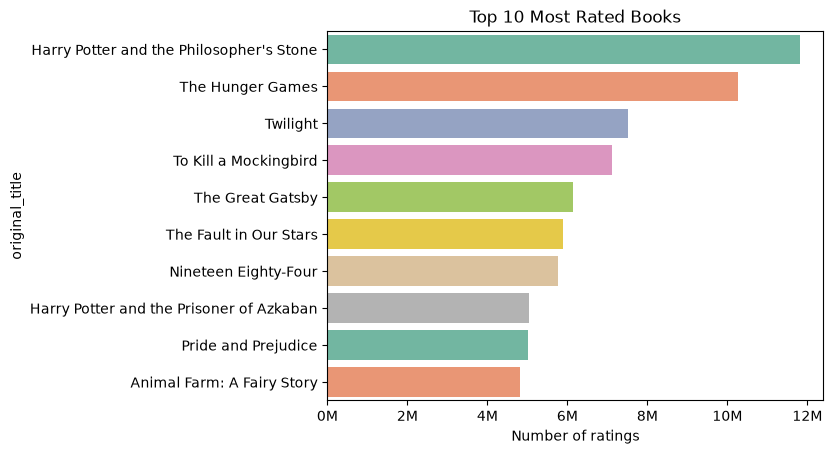

In [17]:
df2 = df.copy()

plot1 = df2[['original_title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='ratings_count', y='original_title', hue='original_title', palette="Set2")
ax.set_xlabel("Number of ratings")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_title("Top 10 Most Rated Books")

plt.show()

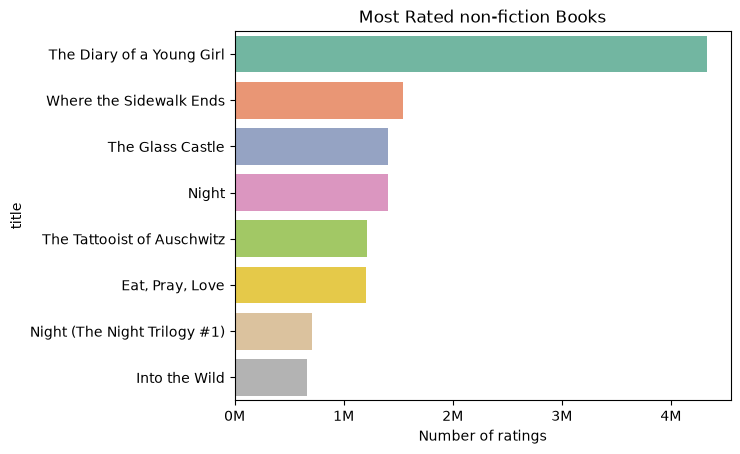

In [21]:
df2 = df.copy()
df2 = df2[df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].eq('non-fiction').any(axis=1)]

plot1 = df2[['title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(8)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='ratings_count', y='title', hue='title', palette="Set2")
ax.set_xlabel("Number of ratings")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_title("Most Rated non-fiction Books")

plt.show()

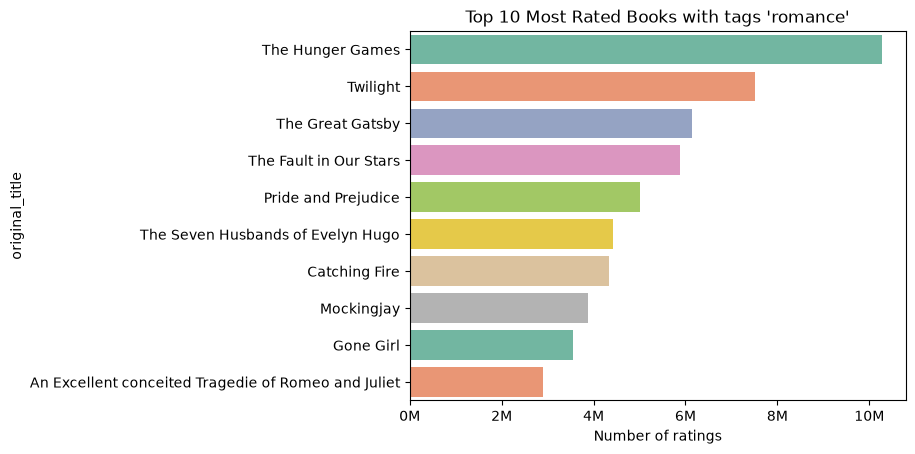

In [22]:
df2 = df.copy()
df2 = df2[df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].eq('romance').any(axis=1)]

plot1 = df2[['original_title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='ratings_count', y='original_title', hue='original_title', palette="Set2")
ax.set_xlabel("Number of ratings")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_title("Top 10 Most Rated Books with tags 'romance'")

plt.show()

average_rating

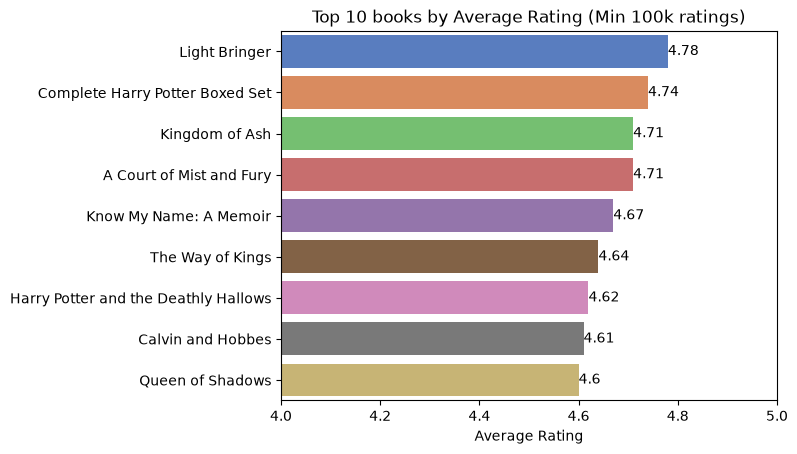

In [77]:
df2 = df.copy()

plot1 = df2[df2['ratings_count'] > 100000][['original_title', 'average_rating']].sort_values(by='average_rating', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='average_rating', y='original_title', hue='original_title', palette='muted')
ax.set_xlim(4, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Top 10 books by Average Rating (Min 100k ratings)")

plt.show()

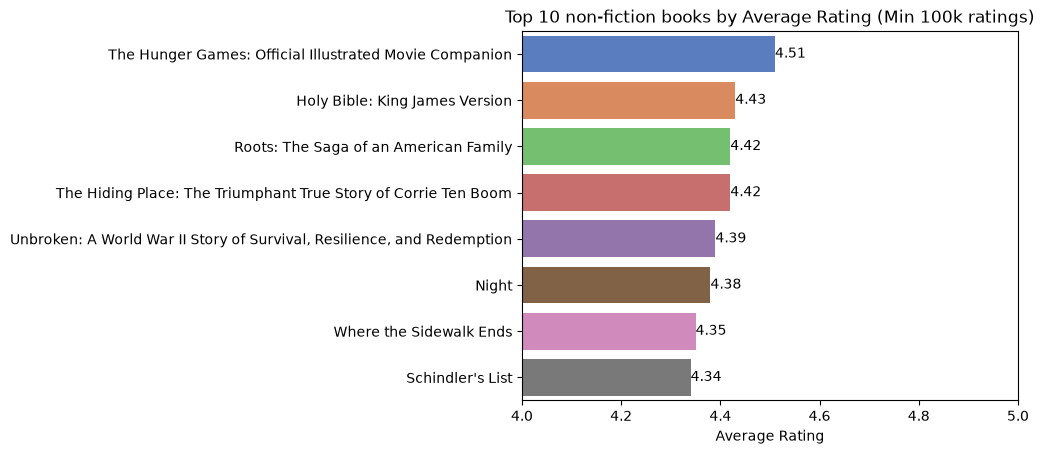

In [61]:
df2 = df.copy()
df2 = df2[df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].eq('non-fiction').any(axis=1)]

plot1 = df2[df2['ratings_count'] > 100000][['title', 'average_rating']].sort_values(by='average_rating', ascending=False).head(8)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='average_rating', y='title', hue='title', palette='muted')
ax.set_xlim(4, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Top 10 non-fiction books by Average Rating (Min 100k ratings)")

plt.show()

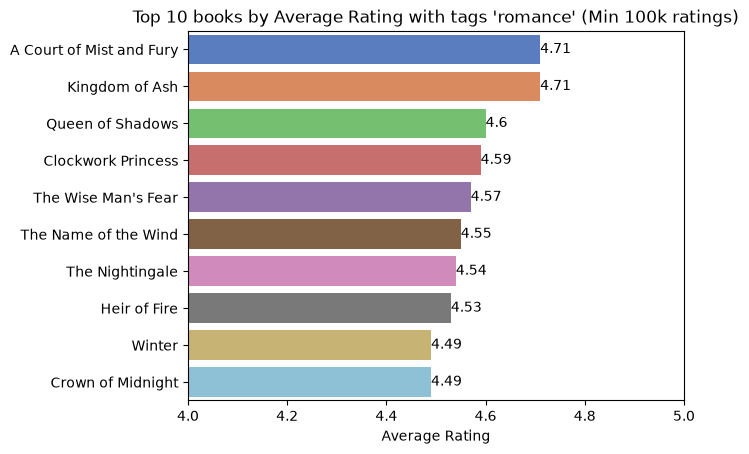

In [76]:
df2 = df.copy()
df2 = df2.drop_duplicates(subset=['book_id'])
df2 = df2[df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].eq('romance').any(axis=1)]

plot1 = df2[df2['ratings_count'] > 100000][['original_title', 'average_rating']].sort_values(by='average_rating', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='average_rating', y='original_title', hue='original_title', palette='muted')
ax.set_xlim(4, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Top 10 books by Average Rating with tags 'romance' (Min 100k ratings)")

plt.show()

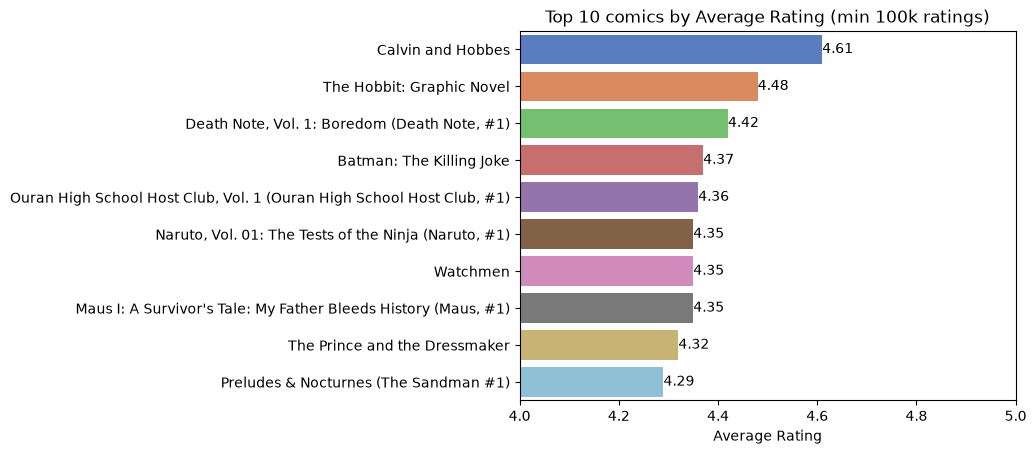

In [78]:
df2 = df.copy()
df2 = df2[df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].eq('comics').any(axis=1)]

plot1 = df2[df2['ratings_count'] > 100000][['title', 'average_rating']].sort_values(by='average_rating', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='average_rating', y='title', hue='title', palette='muted')
ax.set_xlim(4, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Top 10 comics by Average Rating (min 100k ratings)")

plt.show()

### Book Characteristics

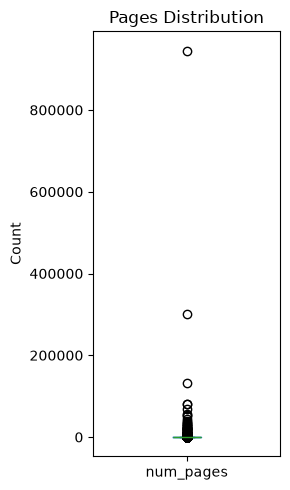

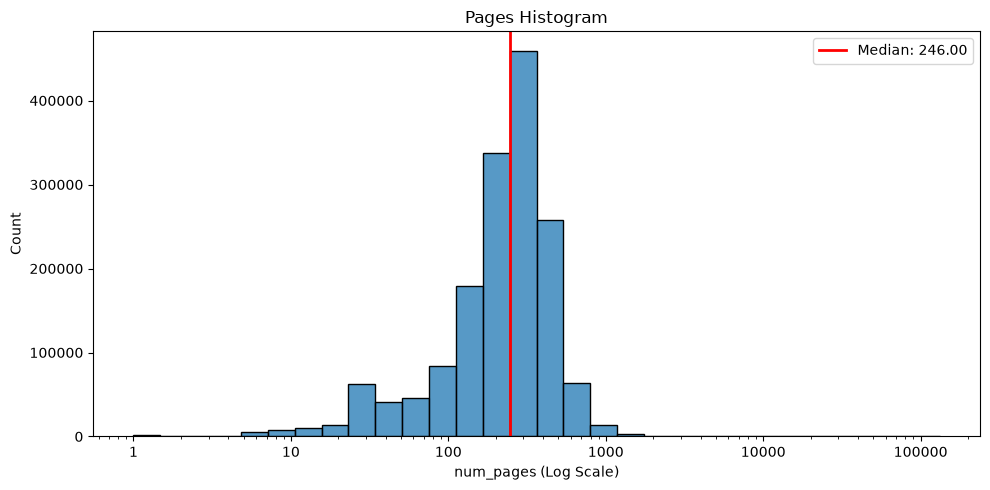

In [79]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(3,5))

df2['num_pages'].plot(kind='box')
ax.set_title('Pages Distribution')
ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2[(df2['num_pages'] > 0) & (df2['num_pages'] < 200_000)]['num_pages'], bins=30, log_scale=True, ax=ax)
ax.set_xlabel('num_pages (Log Scale)')
ax.axvline(df2['num_pages'].median(), color='red', linestyle='-', linewidth=2, label=f'Median: {df2['num_pages'].median():.2f}')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}'))
ax.set_title('Pages Histogram')
ax.legend()
plt.tight_layout()
plt.show()

### Genre Analysis

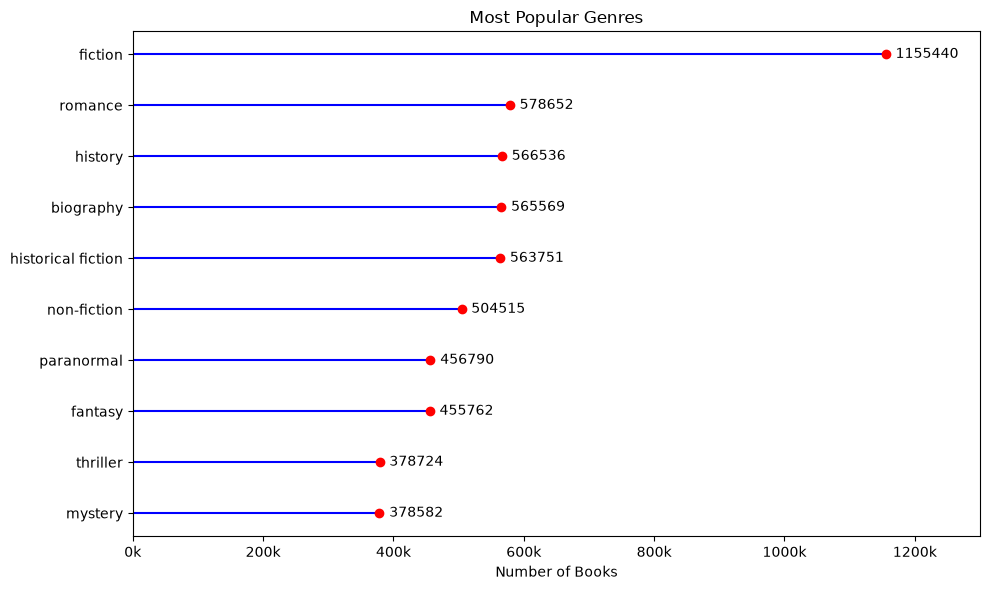

In [80]:
df2 = df.copy()
genre_counts = df2[["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].melt(value_name="genre")["genre"].dropna().value_counts().head(10).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hlines(y=genre_counts.index, xmin=0, xmax=genre_counts.values, color="blue",)
ax.plot(genre_counts.values, genre_counts.index, "o", color="red",)
ax.set_xlabel("Number of Books")
ax.set_xlim(0, 1_300_000)
for i, (genre, val) in enumerate(genre_counts.items()):
    ax.text(val + 15000, i, f"{val}",va="center")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}k'))
ax.set_title("Most Popular Genres")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

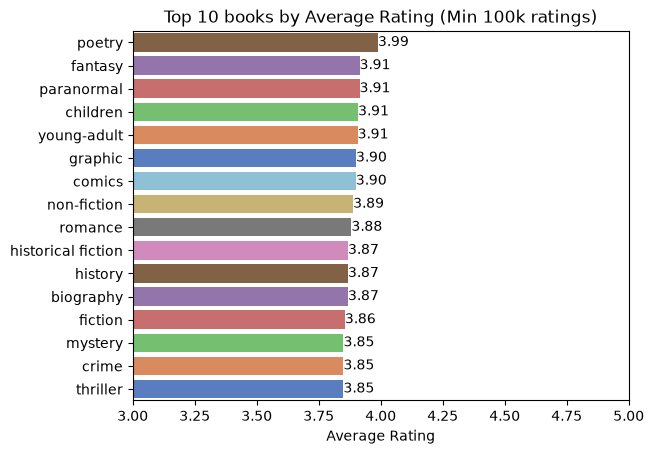

In [81]:
df2 = df.copy()
df_genre_rating = (df2[["average_rating"] + ["genre_1", "genre_2", "genre_3", "genre_4", "genre_5"]].melt(id_vars="average_rating",value_name="genre").dropna(subset=["genre", "average_rating"]))
plot1 = (df_genre_rating.groupby("genre").agg(
                    avg_rating = ("average_rating", "mean"), 
                    book_count=("average_rating", "count"))
                )
plot1 = plot1.sort_values("avg_rating", ascending=False).sort_values("avg_rating")

fig, ax = plt.subplots()
sns.barplot(data=plot1, x='avg_rating', y='genre', hue='genre', palette='muted')
ax.set_xlim(3, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
ax.set_title("Top 10 books by Average Rating (Min 100k ratings)")
plt.gca().invert_yaxis()
plt.show()

### Temporal Analysis

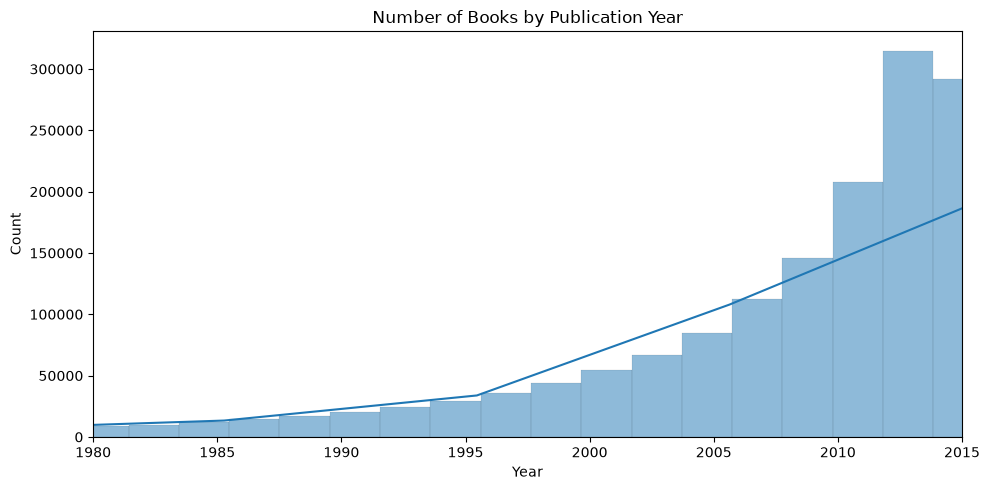

In [82]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2['publication_year'], bins=1000, kde=True)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xlim(1980, 2015)
ax.set_title('Number of Books by Publication Year')

plt.tight_layout()
plt.show()

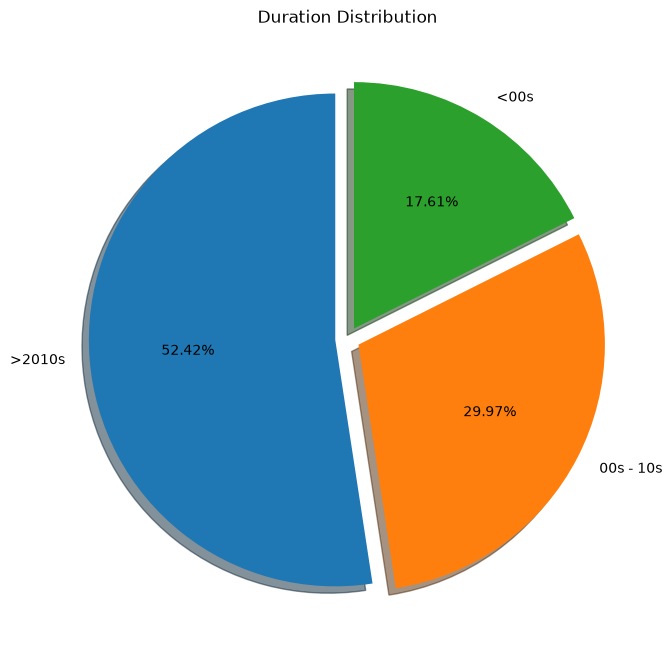

In [83]:
df2 = df.copy()
df2 = df2[df2['publication_year'].notna()]
df2['publication_year_category'] = np.where(df2['publication_year'] > 2010, '>2010s', np.where(df2['publication_year'] > 2000, '00s - 10s', '<00s'))

fig, ax = plt.subplots(figsize=(8,8))
explode_values = (0.05, 0.05, 0.05)
df2['publication_year_category'].value_counts().plot(kind='pie', startangle=90, autopct='%1.2f%%', shadow=True, explode=explode_values)
ax.set_ylabel('')
ax.set_title('Duration Distribution')
plt.show()

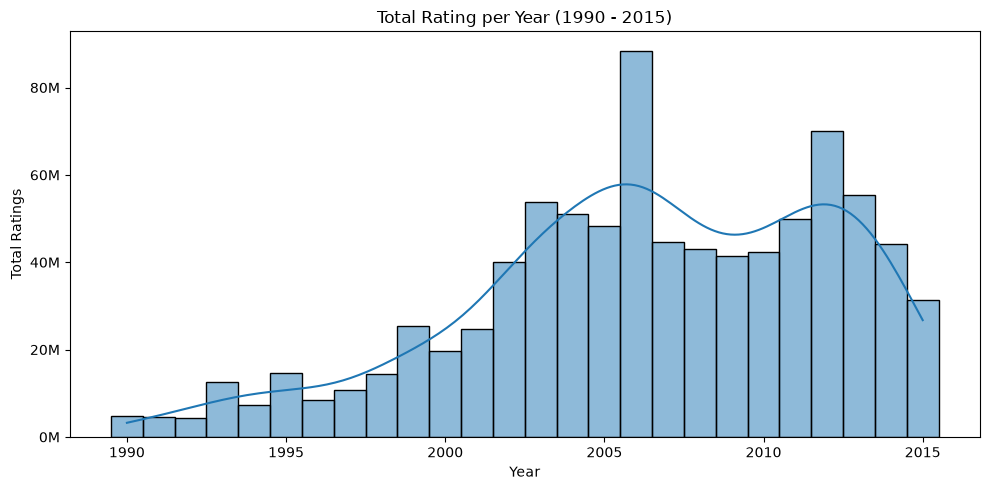

In [84]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df2[(df2['publication_year'] >= 1990) & (df2['publication_year'] <= 2015)], x='publication_year', weights='ratings_count', discrete=True, kde=True, ax=ax)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_xlabel('Year')
ax.set_ylabel('Total Ratings')
ax.set_title('Total Rating per Year (1990 - 2015)')

plt.tight_layout()
plt.show()

### Author / Series

In [8]:
df_author = df[["book_id", "author_names", "average_rating", "ratings_count"]].copy()
df_author = df_author.explode("author_names")

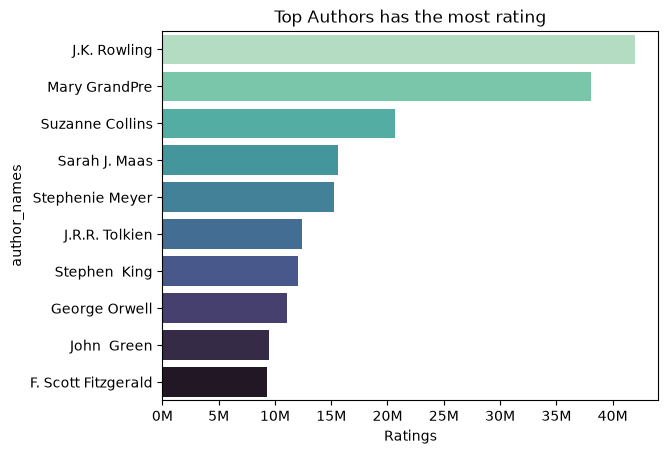

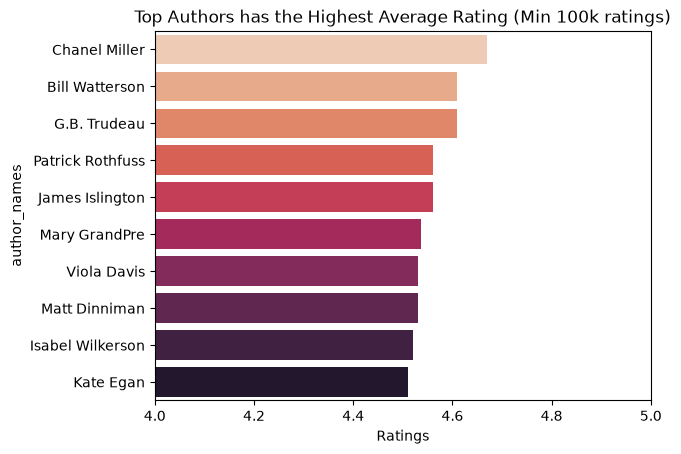

In [9]:
df2 = df_author.copy()

plot1 = df2.groupby('author_names')['ratings_count'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="mako_r")
ax.set_xlabel("Ratings")
ax.set_title("Top Authors has the most rating")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
plt.show()

plot1 = df2[df2['ratings_count'] > 100000].groupby('author_names')['average_rating'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="rocket_r")
ax.set_xlabel("Ratings")
ax.set_title("Top Authors has the Highest Average Rating (Min 100k ratings)")
ax.set_xlim(4, 5)
plt.show()

In [10]:
df_series = df[["book_id", "series_names", "average_rating", "ratings_count"]].copy()
df_series = df_series.explode("series_names")

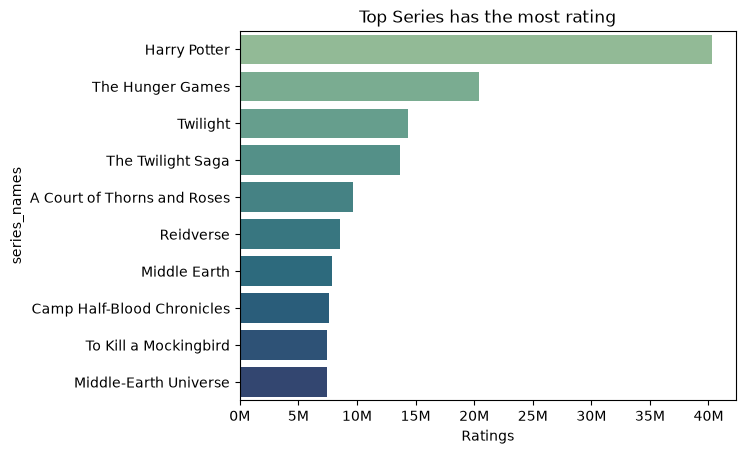

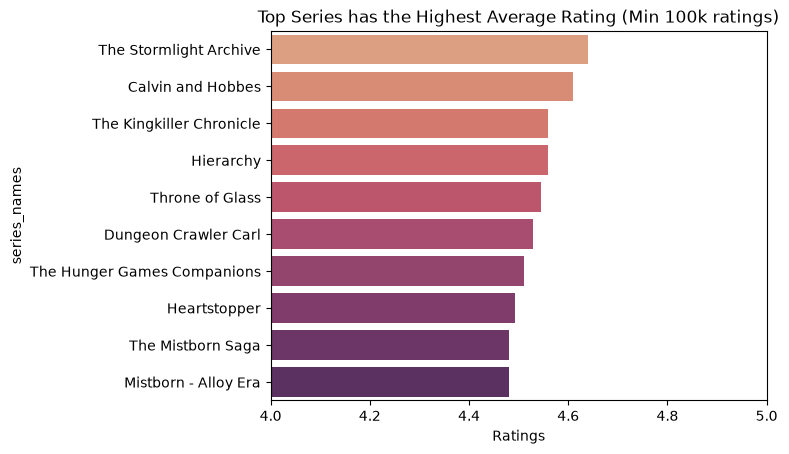

In [11]:
df2 = df_series.copy()

plot1 = df2.groupby('series_names')['ratings_count'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="crest")
ax.set_xlabel("Ratings")
ax.set_title("Top Series has the most rating")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
plt.show()

plot1 = df2[df2['ratings_count'] > 100000].groupby('series_names')['average_rating'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="flare")
ax.set_xlabel("Ratings")
ax.set_title("Top Series has the Highest Average Rating (Min 100k ratings)")
ax.set_xlim(4, 5)
plt.show()

### Metadata

In [12]:
df['language_code'].value_counts(ascending=False).head(20)

language_code
eng      711171
en-US     91452
en-GB     58358
spa       54531
ita       50905
ara       42978
fre       32056
ger       30978
ind       27291
por       23452
nl        17497
tur       14238
per       11821
fin       11611
gre       10024
swe        9915
cze        8564
en-CA      7652
jpn        7217
bul        7105
Name: count, dtype: int64[pyarrow]

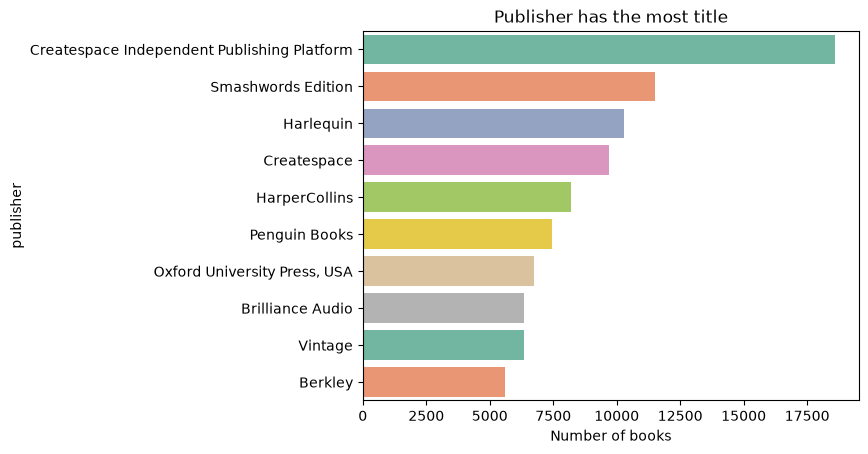

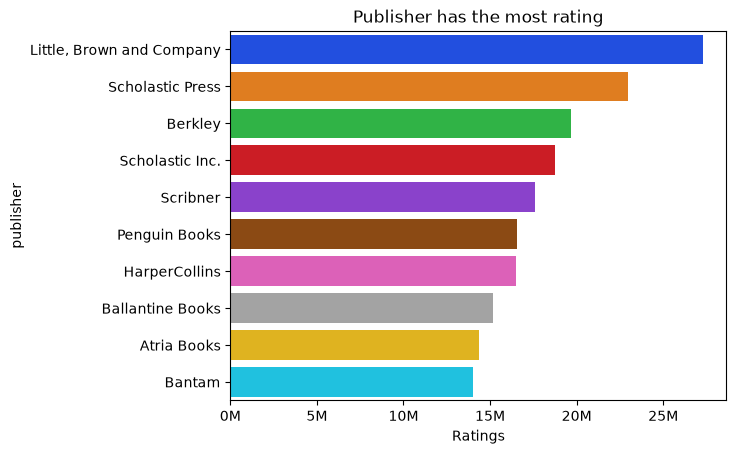

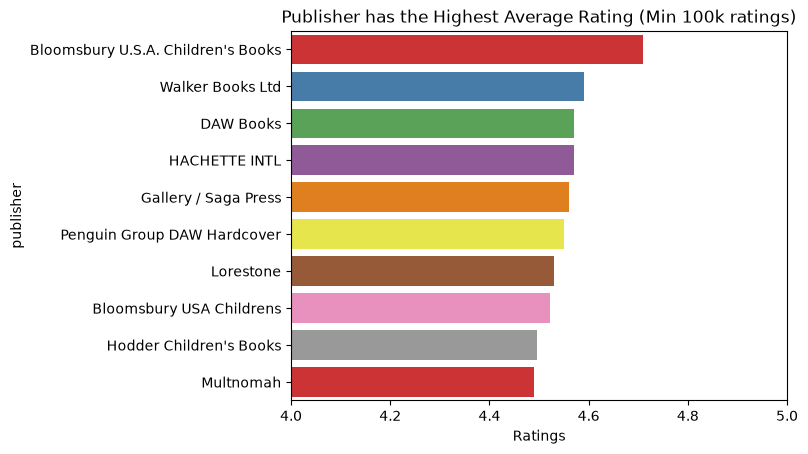

In [13]:
df2 = df.copy()

plot1 = df2['publisher'].value_counts(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set2")
ax.set_xlabel("Number of books")
ax.set_title("Publisher has the most title")
plt.show()

plot1 = df2.groupby('publisher')['ratings_count'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="bright")
ax.set_xlabel("Ratings")
ax.set_title("Publisher has the most rating")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
plt.show()

plot1 = df2[df2['ratings_count'] > 100000].groupby('publisher')['average_rating'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set1")
ax.set_xlabel("Ratings")
ax.set_title("Publisher has the Highest Average Rating (Min 100k ratings)")
ax.set_xlim(4, 5)
plt.show()